# Time Series Forecasting with an LSTM in PyTorch

## Objective

 Build and train an LSTM model in PyTorch to perform one-step-ahead forecasting on a synthetic temperature-like time series.

The goal is to use previous timesteps to predict the next timestep.

In [ ]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


## Dataset Description

Generate a synthetic time series that represents a temperature signal with:

- a seasonal daily/periodic pattern
- a slow upward trend
- random Gaussian noise

Use:

$$
y(t) = 0.02t + \sin(0.2t) + 0.5\cos(0.05t) + \epsilon
$$

where:

$$
\epsilon \sim \mathcal N(0,\ 0.1)
$$

Use the following settings:

- Total timesteps: 6000
- Sequence length: 30
- Random seed: 42

---

In [ ]:
np.random.seed(42)

In [ ]:
total_time_steps = 6000
t = np.linspace(0,100,total_time_steps)
y = 0.02*t + np.sin(0.2*t) + 0.5 * np.cos(0.05*t) + np.random.normal(0,0.1)


## Sequence Construction

Convert the raw time series into supervised learning sequences using a sliding window.

Each input sequence should contain:

$$
[y_t, y_{t+1}, \dots, y_{t+29}]
$$

The target should be:

$$
y_{t+30}
$$

Example:

| Input Sequence | Target |
|---|---|
| $[y_0, y_1, \dots, y_{29}]$ | $y_{30}$ |
| $[y_1, y_2, \dots, y_{30}]$ | $y_{31}$ |

---

In [ ]:
sequence_length = 30
X = []
targets = []

In [ ]:
for i in range(len(y) - sequence_length):
  X.append(y[i:i + sequence_length])
  targets.append(y[i+sequence_length])

In [ ]:
X = np.array(X)
targets = np.array(targets)
X = X.reshape(X.shape[0], X.shape[1], 1)
targets = targets.reshape(-1, 1)

In [ ]:
print("X shape:", X.shape)
print("Targets shape:", targets.shape)

X shape: (5970, 30, 1)
Targets shape: (5970, 1)


### Dataset Preparation

1. Generate the synthetic temperature-like time series.
2. Create sliding-window sequences.
3. Perform a train/validation/test split.

Suggested split proportions:

- 70% training
- 15% validation
- 15% test

4. Convert all arrays into PyTorch tensors.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X,targets,test_size=0.3, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5,random_state = 42)

In [ ]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_val = torch.tensor(X_val, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_val = torch.tensor(y_val, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)

In [ ]:
y_train = y_train.view(-1, 1)
y_val = y_val.view(-1, 1)
y_test = y_test.view(-1, 1)

In [ ]:
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_val: {X_val.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_val: {y_val.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: torch.Size([4179, 30, 1])
Shape of X_val: torch.Size([895, 30, 1])
Shape of X_test: torch.Size([896, 30, 1])
Shape of y_train: torch.Size([4179, 1])
Shape of y_val: torch.Size([895, 1])
Shape of y_test: torch.Size([896, 1])


## LSTM Model Construction

Build a recurrent model using:

- `nn.LSTM`
- `batch_first=True`
- hidden size = 64
- number of recurrent layers = 1

After the LSTM layer, use a fully connected layer to produce the final regression prediction.

In [ ]:
class Time_Series_LSTM(nn.Module):
  def __init__(self,input_size, hidden_size, output_size, num_layers):
    super(Time_Series_LSTM,self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    self.lstm = nn.LSTM(input_size,hidden_size,num_layers, batch_first = True)
    self.fc= nn.Linear(hidden_size, output_size)

  def forward(self,x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
    c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
    out, (hnn,cn) = self.lstm(x, (h0,c0))
    out = self.fc(out[:,-1,:])
    return out

## Training

Train the model using:

- Loss Function: Mean Squared Error (`MSELoss`)
- Optimizer: Adam
- Learning Rate: 0.001
- Epochs: 1000

During training:

- track training loss
- track validation loss
- print losses every 100 epochs

---

In [ ]:
model = Time_Series_LSTM(input_size = 1, hidden_size = 64, output_size = 1, num_layers = 1)
loss_func = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [ ]:
epochs = 1000
training_losses = []
validation_losses = []

for epoch in range(epochs):
  model.train()
  y_pred = model(X_train)
  train_loss = loss_func(y_pred, y_train)
  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()
  training_losses.append(train_loss.item())

  model.eval()
  with torch.no_grad():
    val_pred = model(X_val)
    val_loss = loss_func(val_pred, y_val)
    validation_losses.append(val_loss.item())

    if (epoch + 1) % 100 == 0:
      print(
          f"Epoch [{epoch+1}/1000], "
          f"Train Loss: {train_loss.item():.4f}, "
          f"Val Loss: {val_loss.item():.4f}")

Epoch [100/1000], Train Loss: 0.0128, Val Loss: 0.0129
Epoch [200/1000], Train Loss: 0.0005, Val Loss: 0.0005
Epoch [300/1000], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [400/1000], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [500/1000], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [600/1000], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [700/1000], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [800/1000], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [900/1000], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [1000/1000], Train Loss: 0.0000, Val Loss: 0.0000


## Evaluation

Evaluate the trained model on the test set.

Report:

| Metric | Value |
|---|---:|
| Test MSE |  |
| Test RMSE |  |

---

## Expected Results

A correctly implemented model should show:

- decreasing training loss
- decreasing validation loss
- validation loss that follows training loss closely
- reasonable test forecasting performance

Because this signal has a trend and multiple periodic components, the LSTM should learn the structure well.

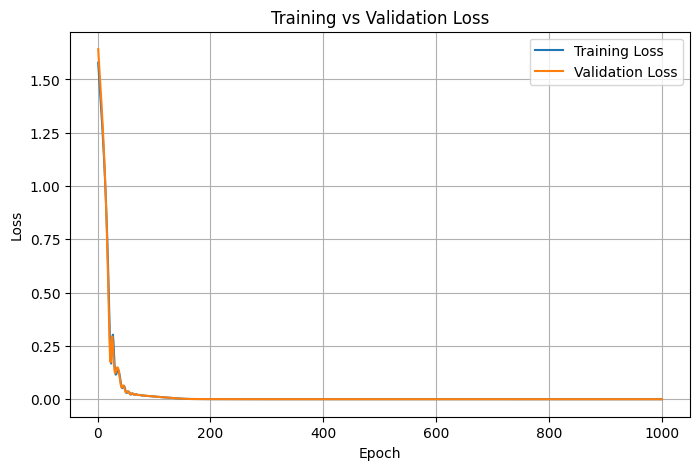

In [ ]:
epochs = range(1, len(training_losses) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, training_losses, label="Training Loss")
plt.plot(epochs, validation_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
model.eval()
with torch.no_grad():
  y_pred = model(X_test)
  test_loss = loss_func(y_pred,y_test)
  print(f"Test Loss: {test_loss.item():.4f}")

# Convert tensors to NumPy
y_test_np = y_test.numpy()
y_pred_np = y_pred.numpy()

# Metrics
mse = mean_squared_error(y_test_np, y_pred_np)
rmse = np.sqrt(mse)

print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test Loss: 0.0000
Test MSE: 0.0000
Test RMSE: 0.0070
